# How reliable is "the best model"? Premier League age vs FPL price
## Module 5: Assessing Model Performance
Module 05 picks the best model from one train/test split. I test whether that pick changes if you split the data differently, using Premier League age and FPL price data.


## Step 1: Libraries
numpy for the math, pandas for tables, matplotlib for charts. The seed makes the random splits come out the same every run.

In [10]:
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)


## Step 2: Get the data
Downloading every player from the official Fantasy Premier League API and keeping name, position, birth date and price.

In [11]:
url = "https://fantasy.premierleague.com/api/bootstrap-static/"
request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
data = json.load(urllib.request.urlopen(request))

players = pd.DataFrame(data["elements"])
players = players[["web_name", "element_type", "birth_date", "now_cost"]]
players.head()

,web_name,element_type,birth_date,now_cost
0,Raya,1,1995-09-15,61
1,Arrizabalaga,1,1994-10-03,49
2,Meslier,1,2000-03-02,49
3,Gabriel,2,1997-12-19,80
4,J.Timber,2,2001-06-17,65


## Step 3: Clean the data
Removing players with no birth date and goalkeepers (priced on a different scale). Calculating age and converting price to £m. Saving a copy of the data used.

In [12]:
players = players.dropna(subset=["birth_date"])
players = players[players["element_type"] != 1]

players["age"] = (pd.Timestamp.today() - pd.to_datetime(players["birth_date"])).dt.days / 365.25
players["price"] = players["now_cost"] / 10

players.to_csv("fpl_players.csv", index=False)
print(len(players), "players")

580 players


## Step 4: Look at the data
Price rises into the mid-to-late twenties and falls after, so the relationship is curved. That's why polynomials of different degrees make sense here.

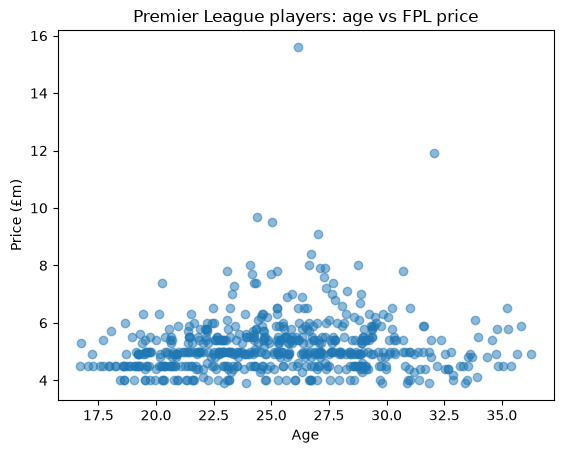

In [13]:
plt.scatter(players["age"], players["price"], alpha=0.5)
plt.xlabel("Age")
plt.ylabel("Price (£m)")
plt.title("Premier League players: age vs FPL price")
plt.show()

## Step 5: Reproduce Module 05
One random 50/50 train/test split. Fit polynomials of degree 1 to 8 on the training half with OLS (np.polyfit) and record train and test MSE for each. Age is rescaled first so high powers don't get huge.

In [14]:
x = players["age"].values
y = players["price"].values
x = (x - x.mean()) / x.std()

degrees = list(range(1, 9))

def one_split(x, y):
    shuffled = np.random.permutation(len(x))
    half = len(x) // 2
    train, test = shuffled[:half], shuffled[half:]

    train_mse, test_mse = [], []
    for d in degrees:
        coefs = np.polyfit(x[train], y[train], d)
        train_mse.append(np.mean((y[train] - np.polyval(coefs, x[train])) ** 2))
        test_mse.append(np.mean((y[test] - np.polyval(coefs, x[test])) ** 2))
    return train_mse, test_mse

Running it once. Like the module's "Sweep flexibility" button.

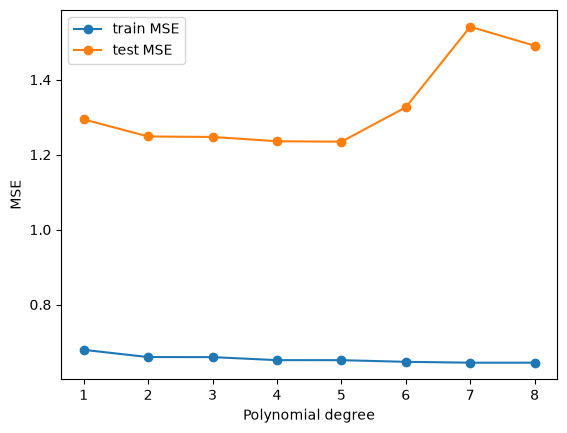

This split says the best degree is 5


In [15]:
train_mse, test_mse = one_split(x, y)

plt.plot(degrees, train_mse, "o-", label="train MSE")
plt.plot(degrees, test_mse, "o-", label="test MSE")
plt.xlabel("Polynomial degree")
plt.ylabel("MSE")
plt.legend()
plt.show()

print("This split says the best degree is", degrees[np.argmin(test_mse)])

## Step 6: Repeat the split 200 times
Same players, different random split each time. If the best degree were reliable, every split would pick the same one. Same idea as the bootstrap in OLS_exploration: repeat and look at the spread.

In [16]:
single_split_picks = []
for i in range(200):
    train_mse, test_mse = one_split(x, y)
    single_split_picks.append(degrees[np.argmin(test_mse)])

pd.Series(single_split_picks).value_counts().sort_index()

1      8
2     36
3     11
4    117
5      8
6     15
7      4
8      1
Name: count, dtype: int64

## Step 7: 5-fold cross-validation
Not covered in the module. Split the players into 5 groups, let each take a turn as the test set, and average the 5 errors. Every player gets tested once, so the result depends less on which split you got. Also repeated 200 times.

In [17]:
def cross_validation(x, y, k=5):
    shuffled = np.random.permutation(len(x))
    folds = np.array_split(shuffled, k)

    cv_mse = []
    for d in degrees:
        errors = []
        for test in folds:
            train = np.setdiff1d(shuffled, test)
            coefs = np.polyfit(x[train], y[train], d)
            errors.append(np.mean((y[test] - np.polyval(coefs, x[test])) ** 2))
        cv_mse.append(np.mean(errors))
    return cv_mse

cv_picks = []
for i in range(200):
    cv_mse = cross_validation(x, y)
    cv_picks.append(degrees[np.argmin(cv_mse)])

## Step 8: Compare
How often each degree won under each method. Blue is the single split, orange is cross-validation.

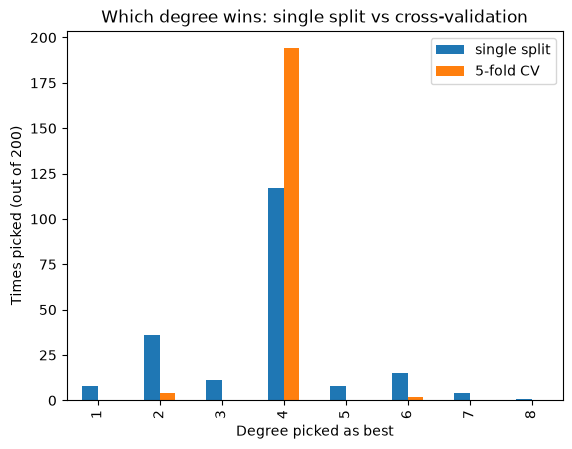

,single split,5-fold CV
1,8,0
2,36,4
3,11,0
4,117,194
5,8,0
6,15,2
7,4,0
8,1,0


In [18]:
comparison = pd.DataFrame({
    "single split": pd.Series(single_split_picks).value_counts(),
    "5-fold CV": pd.Series(cv_picks).value_counts(),
}).reindex(degrees).fillna(0).astype(int)

comparison.plot(kind="bar")
plt.xlabel("Degree picked as best")
plt.ylabel("Times picked (out of 200)")
plt.title("Which degree wins: single split vs cross-validation")
plt.show()

comparison

## Findings
- In the first train/test split, degree 5 gave the best prediction of FPL price from player age.
- When I repeated the split 200 times, the best degree changed depending on which players were in the training and test groups. Degree 4 was chosen the most often.
- With 5-fold cross-validation, degree 4 was chosen 194 out of 200 times. This means it gave a much more consistent result.
- My main takeaway is that using just one split can give a different answer depending on which players are selected. Cross-validation gives a more reliable idea of which model works best for predicting FPL price from age.